# Task

***"Implement the core training loop of word2vec in pure NumPy (no PyTorch / TensorFlow or other ML frameworks).
The applicant is free to choose any suitable text dataset.
The task is to implement the optimization procedure (forward pass, loss, gradients, and parameter updates) for a standard word2vec variant (e.g. skip-gram with negative sampling or CBOW)."***

Word2Vec is a machine learning technique used to learn **word embeddings**, which are vector representations of words. The goal is to represent words in a continuous vector space such that words with similar meanings or contexts have similar vectors.

In this project, I implement the **Skip-Gram model with Negative Sampling**. In the Skip-Gram architecture, the model takes a center word and tries to predict the words that appear in its surrounding context window. By learning which words tend to appear together, the model gradually learns meaningful semantic representations.

---

## Dataset

For this implementation, the model is trained on the story **Little Red Riding Hood**. Although the dataset is relatively small, it is sufficient to illustrate how Word2Vec learns relationships between words.

The text is processed through the following steps:

1. **Split the text into sentences**
2. **Tokenize the sentences into words**
3. **Remove common stopwords** such as *a, the, is, on,* etc. These words appear very frequently but carry little semantic meaning, and removing them simplifies the learning process for this small experiment.
4. **Build a vocabulary** by assigning each word a unique index (word → index mapping)

This processed text is then used to generate training pairs for the Skip-Gram model.

In [1]:
import re

def load_text_file(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    return text

def split_into_sentences(text):
    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip().lower() for s in sentences if s.strip()]
    return sentences

def tokenize(sentence):
    # Keep only alphabetic words
    return re.findall(r"[a-zA-Z]+", sentence.lower())


def build_vocab(tokenized_sentences):
    vocab = {}
    idx = 0
    for sentence in tokenized_sentences:
        for word in sentence:
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab


def generate_training_pairs(tokenized_sentences, word2idx, window_size=5):
    pairs = []

    for tokens in tokenized_sentences:
        for i in range(len(tokens)):
            center_idx = word2idx[tokens[i]]

            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)

            for j in range(start, end):
                if j != i:
                    context_idx = word2idx[tokens[j]]
                    pairs.append((center_idx, context_idx))

    return pairs


## Skip-Gram Training Pairs

In the Skip-Gram model, the goal is to train a **center word** to predict the **words that appear in its surrounding context**.  
The number of surrounding words considered is controlled by the **window size**.

To illustrate this, consider the following sentence:

***"Little Red Riding Hood with wine and biscuits"***

<p align="center">
<img src="Sentence.jpg" width="500">
<br>
<em>Figure 1: Skip-Gram context window illustration</em>
</p>

If we choose the word **"Hood"** as the center word and use a window size of **3**, the model will try to predict the words that appear within three positions of the center word.

The words **"Little", "Red", "Riding", "with", "wine", and "and"** fall within this context window and are therefore considered **context words** for **"Hood"**.  
The word **"biscuits"** lies outside the window and is not included as a context word.

---

For example, using the sentence:

***"Little Red Riding Hood with wine and biscuits"***

and a **window size of 1**, the following training pairs are created:

***Center Word → Context Word***

In [31]:
#create pairs and print for SimpleText.txt
text = load_text_file("SimpleText.txt")
sentences = split_into_sentences(text)
tokenized_sentences = [tokenize(s) for s in sentences]
word2idx = build_vocab(tokenized_sentences)
idx2word = {idx: word for word, idx in word2idx.items()}
training_pairs = generate_training_pairs(tokenized_sentences, word2idx, window_size=1)
print("Training Pairs (center_word ,  context_word):")
for center_idx, context_idx in training_pairs:
    center_word = idx2word[center_idx]
    context_word = idx2word[context_idx]
    print(f"({center_word} ,  {context_word})")

Training Pairs (center_word ,  context_word):
(little ,  red)
(red ,  little)
(red ,  riding)
(riding ,  red)
(riding ,  hood)
(hood ,  riding)
(hood ,  with)
(with ,  hood)
(with ,  wine)
(wine ,  with)
(wine ,  and)
(and ,  wine)
(and ,  biscuits)
(biscuits ,  and)


## Skip-Gram Architecture

The goal of the model is to take a **center word** and predict the **words that appear in its context**.

For example, given the center word **"Hood"**, the model should predict the surrounding words:

**"Little", "Red", "Riding", "with", "wine", "and"**

<p align="center">
<img src="easy.jpg" width="350">
<br>
<em>Figure 2: Skip-Gram prediction objective</em>
</p>

To learn this task, the Skip-Gram model uses two matrices:

- **Center Word Matrix** \(W_{in}\) of size **\(V * D\)**
- **Context Word Matrix** \(W_{out}\) of size **\(D * V\)**

Where:

- \(V\) is the **vocabulary size**
- \(D\) is the **embedding dimension**

### Center Word Matrix \(W_{in}\)

Each **row** contains the embedding vector of a word when it is used as a **center word**.

### Context Word Matrix \(W_{out}\)

Each **column** contains the embedding vector of a word when it is used as a **context word**.

These two embeddings are initially different. After training, the **center embeddings** \(W_{in}\) are usually kept as the final word embeddings, although the context embeddings also contain useful information.

---

### Computing Context Scores

When the model receives a center word, it selects its embedding from \(W_{in}\) and multiplies it with the matrix \(W_{out}\). This produces a **score for every word in the vocabulary**, indicating how likely that word is to appear in the context.

<p align="center">
<img src="SkipGramScore.jpg" height="500">
<br>
<em>Figure 3: Computing scores for all vocabulary words</em>
</p>

During training, the scores of the **true context words** should become larger than the scores of unrelated words.

---

### Traditional Skip-Gram Training

In the standard Skip-Gram formulation:

1. The center word is selected from \(W_{in}\) (using a one-hot vector or simply its index).
2. Its embedding is multiplied by \(W_{out}\).
3. This produces a **score for every word in the vocabulary**.
4. A **softmax function** converts these scores into probabilities.

The model is then trained using **cross-entropy loss** against the correct context word (represented as a one-hot vector).

However, this approach is computationally expensive. For every training pair, the model must compute:

- **\(V\) dot products of length \(D\)**
- a **softmax over the entire vocabulary**

When \(V\) is large, this becomes very slow and the softmax can suffer from numerical instability due to many exponential operations.

---

### Negative Sampling

To address this issue, **Negative Sampling** reformulates the problem as a **binary classification task**.

Instead of asking:

> *Which word among the entire vocabulary is the correct context word?*

the model asks:

> *Is this word a real context word or a randomly sampled word?*

For each true pair \((center, context)\):

- one **true context word** is used (positive example)
- **\(K\)** additional words are sampled randomly from the vocabulary (negative examples)

The center word embedding is then multiplied with the embeddings of this small subset of words to produce scores. These scores are passed through a **sigmoid function**.

The training objective encourages:

- **high probability for the true context pair**
- **low probability for randomly sampled pairs**

---

### Negative Sampling Loss

The loss for a single training example becomes:

$$
L =
-\log\left(\sigma(\text{true\_context}^{T} \ \text{center\_word})\right)
-
\sum_{k=1}^{K}
\log\left(\sigma(-\text{negative\_context}_{k}^{T} \ \text{center\_word})\right)
$$

The **first term** encourages the score between the center word and the true context word to be high.

The **second term** encourages the scores between the center word and the randomly sampled words to be low.

Through repeated updates, this process pushes embeddings of **related words closer together**, while pushing unrelated words further apart in the embedding space.

---

## Gradient derivation for Negative Sampling

### Derivative of the sigmoid

The sigmoid function is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Its derivative is:

$$
\frac{d\sigma(x)}{dx} = \sigma(x)(1-\sigma(x))
$$

---

### Derivative of the log-sigmoid

For the positive term:
$$
\frac{d}{dx}\left[-\log(\sigma(x))\right]
=
-\frac{1}{\sigma(x)} \cdot \sigma(x)(1-\sigma(x))
=
\sigma(x) - 1
$$
For the negative term:


$$
\frac{d}{dx}\left[-\log(\sigma(-x))\right]
=
-\frac{1}{\sigma(-x)} \cdot \left[-\sigma(-x)(1-\sigma(-x))\right]
=
1 - \sigma(-x)
=
\sigma(x)
$$


---

### Applying the chain rule

For the positive pair:

$$
x = \text{true\_context}^{T}\text{center\_word}
$$

For the negative samples:

$$
x_k = \text{negative\_context}_{k}^{T}\text{center\_word}
$$

---

### Gradient with respect to the center word embedding

$$
\frac{\partial L}{\partial \text{center\_word}}
=
(\sigma(\text{true\_context}^{T}\text{center\_word}) - 1)\,\text{true\_context}
+
\sum_{k=1}^{K}
\sigma(\text{negative\_context}_{k}^{T}\text{center\_word})\,\text{negative\_context}_{k}
$$

---

### Gradient with respect to the true context embedding

$$
\frac{\partial L}{\partial \text{true\_context}}
=
(\sigma(\text{true\_context}^{T}\text{center\_word}) - 1)\,\text{center\_word}
$$

---

### Gradient with respect to the negative context embeddings

$$
\frac{\partial L}{\partial \text{negative\_context}_{k}}
=
\sigma(\text{negative\_context}_{k}^{T}\text{center\_word})\,\text{center\_word}
$$

We now obtain \(2 + K\) gradients that are applied to the different embeddings involved in the training step: the **center word embedding**, the **true context embedding**, and the **\(K\) negative context embeddings**.

At first glance, negative sampling updates fewer parameters than the original Skip-Gram formulation. However, because the negative samples are drawn randomly from the vocabulary, over many training iterations most word embeddings will eventually be updated.

In practice, this means the model can still learn meaningful word representations similar to those produced by the full Skip-Gram objective, but in a much more computationally efficient way. Instead of computing scores for every word in the vocabulary at each training step, the model only updates the embeddings of the center word, the true context word, and a small set of \(K\) sampled negative words.

As a result, the computational cost of each training step drops from \(O(V)\) to \(O(K)\), where \(V\) is the vocabulary size and \(K\) is the number of negative samples

In [3]:
import numpy as np

def sample_negatives(vocab_size, positive_idx, K):
    neg_ids = np.random.randint(0, vocab_size, size=K)
    # resample any accidental positives (rare)
    while np.any(neg_ids == positive_idx):
        neg_ids[neg_ids == positive_idx] = np.random.randint(0, vocab_size, size=np.sum(neg_ids == positive_idx))
    return neg_ids

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

class SkipGram:
    def __init__(self, vocab_size, embedding_dim, optimizer="adam", lr=0.05):
        self.V = vocab_size
        self.D = embedding_dim

        self.W_in = np.random.randn(self.V, self.D) * 0.01
        self.W_out = np.random.randn(self.D, self.V) * 0.01

        self.optimizer_name = optimizer.lower()
        self.lr = lr

        if self.optimizer_name == "adam":
            self.opt = Adam(params=[self.W_in, self.W_out], lr=lr)
        else:
            self.opt = None  # SGD uses lr directly

    def softmax(self, x):
        x = x - np.max(x)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x)

    def forward(self, center_idx):
        center_word = self.W_in[center_idx]           
        scores = np.dot(center_word, self.W_out)      
        y_hat = self.softmax(scores)       
        return y_hat, center_word
    

    def train_step(self, center_idx, context_idx):
        y_hat, center_word = self.forward(center_idx)

        y_true = np.zeros(self.V)
        y_true[context_idx] = 1 #set the objective to the context word in the pair

        error = y_hat - y_true                 

        grad_W_out = np.outer(center_word, error)       
        dh = np.dot(self.W_out, error)         

        grad_W_in = np.zeros_like(self.W_in)   
        grad_W_in[center_idx] = dh

        loss = -np.log(y_hat[context_idx] + 1e-9)
        return loss, grad_W_in, grad_W_out
    
    def train(self, pairs, epochs=200):
        for epoch in range(epochs):
            total_loss = 0.0
            grad_W_in_sum = np.zeros_like(self.W_in)
            grad_W_out_sum = np.zeros_like(self.W_out)

            for center_idx, context_idx in pairs:
                loss, g_in, g_out = self.train_step(center_idx, context_idx)
                total_loss += loss
                grad_W_in_sum += g_in
                grad_W_out_sum += g_out

            # Average gradients
            n = len(pairs)
            grad_W_in = grad_W_in_sum / n
            grad_W_out = grad_W_out_sum / n

            # One update per epoch (SGD or Adam)
            if self.optimizer_name == "adam":
                self.opt.step(params=[self.W_in, self.W_out], grads=[grad_W_in, grad_W_out])
            else:
                self.W_in -= self.lr * grad_W_in
                self.W_out -= self.lr * grad_W_out

            avg_loss = total_loss / n
            print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
        return avg_loss
    
    def train_step_ns(self, center_idx, context_idx, K=5):
        # True Embeddings
        center_word = self.W_in[center_idx]            # center word embedding
        pos_context_embedding = self.W_out[:, context_idx]     # context word embedding (only 1 of the few)

        # Negatives embeddings
        neg_ids = sample_negatives(self.V, context_idx, K)
        neg_k_context_embeddings = self.W_out[:, neg_ids]   # all the negative context embeddings (K of them)

        # We score the positive and negative samples according to our current model
        pos_score = np.dot(pos_context_embedding, center_word)           
        neg_scores = np.dot(neg_k_context_embeddings.T, center_word)      

        # Calculate the loss
        pos_sig = sigmoid(pos_score)          
        neg_sig = sigmoid(-neg_scores)     # minus because we want the probability a pair is fake   
        loss = -np.log(pos_sig + 1e-9) - np.sum(np.log(neg_sig + 1e-9))

        # Gradients
        g_pos = (pos_sig - 1.0)                # scalar

        # d/dx -log(sigmoid(-x)) = sigmoid(x)
        g_negs = sigmoid(neg_scores)           # K negative samples gradients

        # Gradients w.r.t vectors
        grad_v = g_pos * pos_context_embedding + (neg_k_context_embeddings @ g_negs)      
        grad_u_pos = g_pos * center_word                         
        grad_u_negs = np.outer(center_word, g_negs)               

        # Apply SGD updates, we dont use adam here because the updates are sparse and only affect a few rows/columns
        self.W_in[center_idx] -= self.lr * grad_v
        self.W_out[:, context_idx] -= self.lr * grad_u_pos
        self.W_out[:, neg_ids] -= self.lr * grad_u_negs

        return loss

    def train_ns(self, pairs, epochs=5, K=5):
        for epoch in range(epochs):
            total_loss = 0.0

            np.random.shuffle(pairs)

            for center_idx, context_idx in pairs:
                total_loss += self.train_step_ns(center_idx, context_idx, K=K)

            avg_loss = total_loss / len(pairs)
            print(f"Epoch {epoch+1}, NS Loss: {avg_loss:.4f}")
        return avg_loss

    

    def print_embeddings(self, idx2word):
        print("\nWord Embeddings:")
        for idx in range(self.V):
            print(f"{idx2word[idx]}: {self.W_in[idx]}")
            
    def predict_top_k_context_softmax(self, center_word, word2idx, idx2word, k=5):
        center_word = center_word.lower()

        if center_word not in word2idx:
            raise ValueError(f"{center_word} not in vocabulary")

        center_idx = word2idx[center_word]

        y_hat, _ = self.forward(center_idx)

        # Get top-k indices sorted by probability
        top_indices = np.argsort(y_hat)[::-1][:k]

        results = []
        for idx in top_indices:
            results.append((idx2word[idx], y_hat[idx]))

        return results
    
    def predict_top_k_context(self, center_word, word2idx, idx2word, k=5):
        center_word = center_word.lower()

        if center_word not in word2idx:
            raise ValueError(f"{center_word} not in vocabulary")

        center_idx = word2idx[center_word]

        # center word embedding
        center_vec = self.W_in[center_idx]

        # compute compatibility scores with all words
        scores = np.dot(center_vec, self.W_out)  # shape (V,)

        # sort scores descending
        top_indices = np.argsort(scores)[::-1][:k]

        results = []
        for idx in top_indices:
            results.append((idx2word[idx], scores[idx]))

        return results

We will create from scratch also an Adam optimizer for The normal SkipGram

In [4]:
import numpy as np

class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        self.t = 0
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def step(self, params, grads):
        self.t += 1
        lr_t = self.lr

        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g * g)

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            p -= lr_t * m_hat / (np.sqrt(v_hat) + self.eps)

In [ ]:
#create pairs for LittleRedRidingHood.txt
import time
text = load_text_file("LittleRedRidingHood.txt")
sentences = split_into_sentences(text)
tokenized_sentences = [tokenize(s) for s in sentences]
# stopwords
stopwords = {
    "the","a","is","and","of","to","in","that","it","with","as","for","was",
    "on","are","by","this","be","her","he","she","they","we","you","me",
    "my","his","their","our","did"
}

# remove stopwords
tokenized_sentences = [
    [w for w in sentence if w not in stopwords]
    for sentence in tokenized_sentences
]
word2idx = build_vocab(tokenized_sentences)
idx2word = {idx: word for word, idx in word2idx.items()}
training_pairs = generate_training_pairs(tokenized_sentences, word2idx, window_size=3) #we use a window size of 2 
vocab_size = len(word2idx)

for c, o in training_pairs[:10]:
    print(idx2word[c], "->", idx2word[o])

print(f"Total training pairs: {len(training_pairs)}")

# -------- Normal SkipGram --------

model_normal = SkipGram(vocab_size, embedding_dim=10, optimizer="adam", lr=0.01)

start = time.time()

model_normal.train(training_pairs, epochs=1000)

end = time.time()

print(f"\nNormal SkipGram training time: {end - start:.2f} seconds")


# -------- Negative Sampling --------

model_ns = SkipGram(vocab_size, embedding_dim=10, optimizer="adam", lr=0.01)

start = time.time()

model_ns.train_ns(training_pairs, epochs=1000)

end = time.time()

print(f"\nNegative Sampling training time: {end - start:.2f} seconds")


once -> upon
once -> time
once -> there
upon -> once
upon -> time
upon -> there
upon -> sweet
time -> once
time -> upon
time -> there
Total training pairs: 2272
Epoch 1, Loss: 5.5452
Epoch 2, Loss: 5.5446
Epoch 3, Loss: 5.5434
Epoch 4, Loss: 5.5415
Epoch 5, Loss: 5.5387
Epoch 6, Loss: 5.5350
Epoch 7, Loss: 5.5302
Epoch 8, Loss: 5.5244
Epoch 9, Loss: 5.5174
Epoch 10, Loss: 5.5091
Epoch 11, Loss: 5.4997
Epoch 12, Loss: 5.4888
Epoch 13, Loss: 5.4767
Epoch 14, Loss: 5.4631
Epoch 15, Loss: 5.4480
Epoch 16, Loss: 5.4315
Epoch 17, Loss: 5.4134
Epoch 18, Loss: 5.3938
Epoch 19, Loss: 5.3727
Epoch 20, Loss: 5.3499
Epoch 21, Loss: 5.3256
Epoch 22, Loss: 5.2997
Epoch 23, Loss: 5.2723
Epoch 24, Loss: 5.2432
Epoch 25, Loss: 5.2127
Epoch 26, Loss: 5.1806
Epoch 27, Loss: 5.1470
Epoch 28, Loss: 5.1120
Epoch 29, Loss: 5.0756
Epoch 30, Loss: 5.0379
Epoch 31, Loss: 4.9990
Epoch 32, Loss: 4.9588
Epoch 33, Loss: 4.9175
Epoch 34, Loss: 4.8752
Epoch 35, Loss: 4.8320
Epoch 36, Loss: 4.7880
Epoch 37, Loss: 4.74

On my computer, training took 39.29 seconds for the normal Skip-Gram and 56.50 seconds for the negative sampling version, even though negative sampling is usually expected to be faster. This is likely because the dataset is relatively small and the Python implementation introduces some overhead due to random sampling and additional loops.

To evaluate the learned embeddings, we use Principal Component Analysis (PCA) to project the 10 dimensional vectors into two dimensions so that their relationships can be visualized.

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def pca_reduce(X, n_components=2):
    # Center the data
    X_centered = X - np.mean(X, axis=0)

    # Compute covariance matrix
    cov = np.dot(X_centered.T, X_centered) / (X_centered.shape[0] - 1)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvectors by decreasing eigenvalues
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]

    # Keep top components
    W = eigvecs[:, :n_components]

    # Project the data
    X_proj = np.dot(X_centered, W)

    return X_proj

def plot_embeddings_pca(model, idx2word, title,highlight_words=None):
    """
    Plots the word embeddings in 2D using PCA.
    """
    E = model.W_in


    ids = range(E.shape[0])

    coords = pca_reduce(E, n_components=2)

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(ids):
        word = idx2word[idx]

        color = "gray"  # default color

        if highlight_words:
            for c, word_list in highlight_words.items():
                if word in word_list:
                    color = c
                    break

        plt.scatter(coords[i, 0], coords[i, 1], color=color)
        plt.text(coords[i, 0] + 0.01,
                 coords[i, 1] + 0.01,
                 word,
                 fontsize=9,
                 color=color)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

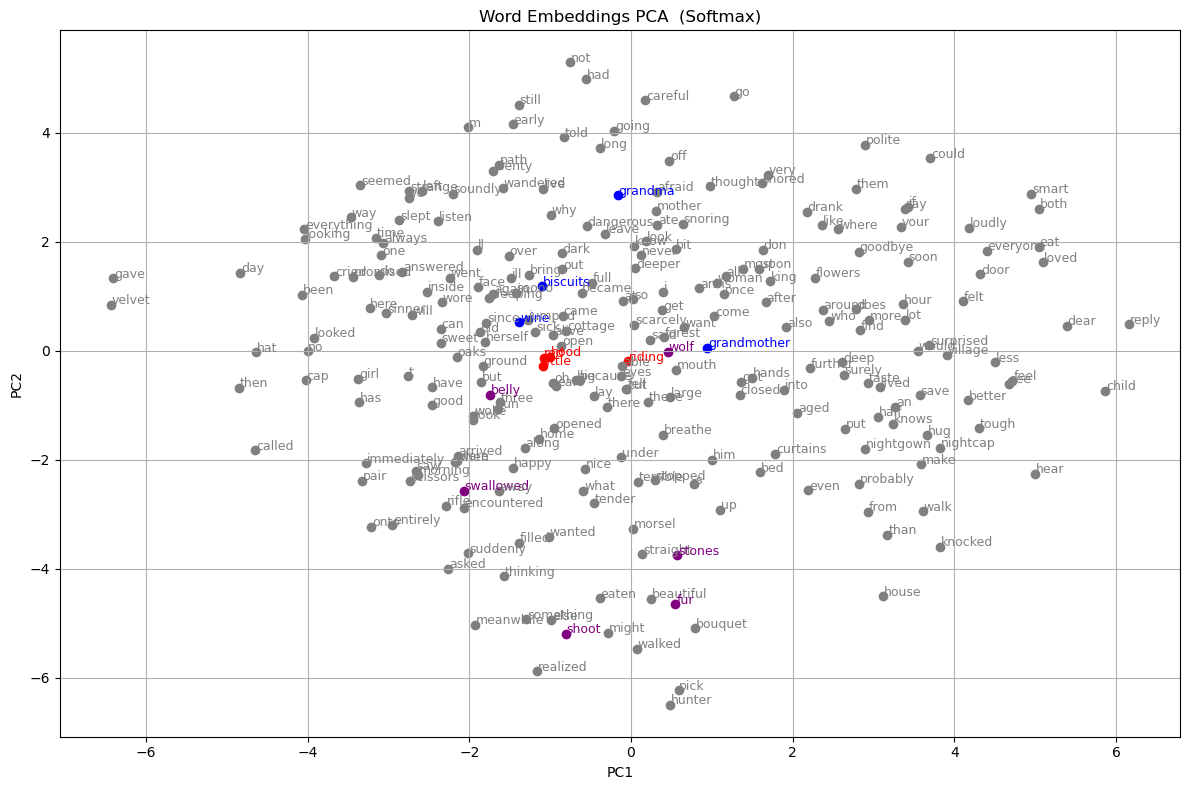

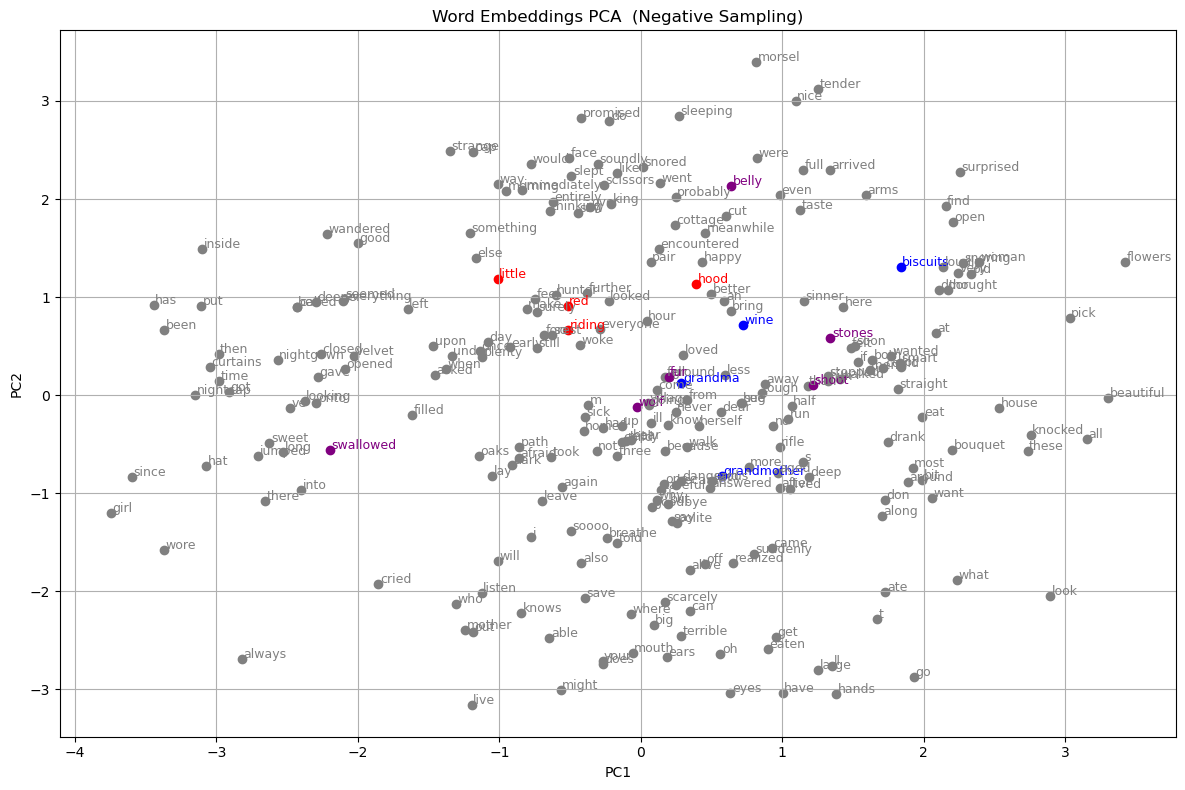

In [27]:
highlight = {
    "red": ["little", "red", "riding", "hood"],
    "purple": ["wolf","fur","belly","shoot","stones","swallowed"],
    "blue": ["grandmother", "grandma","wine","biscuits"]
}

plot_embeddings_pca(model_normal, idx2word, title="Word Embeddings PCA  (Softmax)", highlight_words=highlight)
plot_embeddings_pca(model_ns, idx2word, title="Word Embeddings PCA  (Negative Sampling)", highlight_words=highlight)

I grouped some words related to the wolf, the grandmother, and Little Red Riding Hood. We can see that these words tend to form clusters. Although the distributions differ slightly between the two models, both results still make semantic sense. The Normal skip gram looks slightly better.

To test the model further, we ask our negative sampling model to predict the context words for “grandma”, “wolf”, and “hood”.


In [28]:
top_words = model_ns.predict_top_k_context("hood", word2idx, idx2word, k=5)

print("Top 5 most probable context words:")
for word, prob in top_words:
    print(f"{word}: {prob:.4f}")

Top 5 most probable context words:
little: 2.1817
red: 2.0787
riding: 1.9466
hood: 1.7819
said: 0.5270


We get back the words we had in the simple phrase from the beginning which is a good sign.

In [29]:
top_words = model_ns.predict_top_k_context("wolf", word2idx, idx2word, k=5)

print("Top 5 most probable context words:")
for word, prob in top_words:
    print(f"{word}: {prob:.4f}")

Top 5 most probable context words:
wolf: 3.7408
belly: 1.0170
s: 0.7804
jumped: 0.6979
suddenly: 0.6952


In [30]:
top_words = model_ns.predict_top_k_context("grandma", word2idx, idx2word, k=5)

print("Top 5 most probable context words:")
for word, prob in top_words:
    print(f"{word}: {prob:.4f}")

Top 5 most probable context words:
going: 3.7060
biscuits: 2.8435
m: 2.4394
bring: 2.3362
because: 2.3299


The predicted words are coherent and match the expected context.

---
## Inconclusive Tests

I attempted to perform a grid search to determine the optimal window size and embedding dimension. However, the results consistently selected the largest values for both parameters. This behavior is somewhat suspicious and likely indicates a form of overfitting: larger embedding spaces and wider context windows allow the model to memorize more relationships in the training corpus rather than learn general semantic structure.

Evaluating word embeddings is inherently difficult because there is no straightforward quantitative test that fully captures their quality. There is no single "correct" output to compare against.

In practice, evaluation often relies on qualitative inspection. One common approach is to check whether semantically related words appear close to each other in the embedding space or whether the model retrieves meaningful context words. Another approach is to visualize embeddings using dimensionality reduction techniques such as PCA.

More formal evaluation methods exist (such as word similarity benchmarks or analogy tasks), but implementing them requires external datasets and was outside the scope of this experiment. As a result, evaluating embeddings remains an open and interesting challenge in natural language processing.

In [ ]:
full_text = load_text_file("LittleRedRidingHood.txt")

sentences = split_into_sentences(full_text)
tokenized_sentences = [tokenize(s) for s in sentences]

stopwords = {"the", "a", "is", "and", "of", "to", "in", "that", "it", 
             "with", "as", "for", "was", "on", "are", "by", "this", "be"}

tokenized_sentences = [
    [w for w in sentence if w not in stopwords]
    for sentence in tokenized_sentences
]

word2idx = build_vocab(tokenized_sentences)
idx2word = {idx: word for word, idx in word2idx.items()}
vocab_size = len(word2idx)

# Hyperparameters to test
embedding_dims = [5,10,100,300,600]
window_sizes = [1, 2, 3,4,5]

best_loss = float("inf")
best_config = None

for dim in embedding_dims:
    for window in window_sizes:

        print(f"\nTesting dim={dim}, window={window}")

        model = SkipGram(vocab_size, embedding_dim=dim, optimizer="adam", lr=0.01)

        training_pairs = generate_training_pairs(
            tokenized_sentences, word2idx, window_size=window
        )

        final_loss = model.train_ns(training_pairs, epochs=50)

        print(f"Final Loss: {final_loss:.4f}")

        if final_loss < best_loss:
            best_loss = final_loss
            best_config = (dim, window)

print("\n=========================")
print("Best Configuration:")
print(f"Embedding Dim: {best_config[0]}")
print(f"Window Size: {best_config[1]}")
print(f"Lowest Loss: {best_loss:.4f}")
print("=========================")